In [1]:
# import things
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.mixed_precision import set_global_policy
import tensorflow.keras.backend as K
from patchify import patchify, unpatchify

In [2]:
def f1(y_true, y_pred):
    def recall_m(y_true, y_pred):
        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        Positives = K.sum(K.round(K.clip(y_true, 0, 1)))
        recall = TP / (Positives+K.epsilon())
        return recall
    
    def precision_m(y_true, y_pred):
        TP = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
        Pred_Positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
        precision = TP / (Pred_Positives+K.epsilon())
        return precision
    
    precision, recall = precision_m(y_true, y_pred), recall_m(y_true, y_pred)
    
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

In [3]:
from tensorflow.keras.models import load_model

# Load the model you trained in task5_training.ipynb
patch_size = 256
example_file_name = f'anastasiia_234301_unet_model_{patch_size}px.h5'
model = load_model(example_file_name, custom_objects={"f1": f1})

In [4]:
# Define any functions you need to process the mask e.g. Task 2
def detect_and_crop_petri_dish(image_path):
    # Load the input image in grayscale for easier processing
    image = cv2.imread(image_path, 0)  # Grayscale image for preprocessing
    # Load the original image for output purposes (retain color information)
    original_image = cv2.imread(image_path)  
    
    # Apply a median blur to reduce noise and preserve edges
    blurred = cv2.medianBlur(image, 5)  
    
    # Convert the blurred image to binary using a threshold value
    # Pixels above the threshold become white (255), others become black (0)
    _, binary_image = cv2.threshold(blurred, 150, 255, cv2.THRESH_BINARY)

    # Define a kernel for morphological operations (used to process the binary mask)
    kernel = np.ones((9, 9), np.uint8)
    
    # Dilate the binary image to fill small gaps and connect components
    dilated = cv2.dilate(binary_image, kernel, iterations=3)
    # Perform erosion to close small holes in the binary mask
    closed = cv2.erode(dilated, kernel, iterations=4)
    
    # Find contours in the processed binary image
    # Contours are the boundaries of connected components in the binary mask
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Select the largest contour, assuming it's the Petri dish
    # This works under the assumption that the Petri dish is the largest object in the image
    largest_contour = max(contours, key=cv2.contourArea)
    
    # Calculate the bounding rectangle of the largest contour
    x, y, w, h = cv2.boundingRect(largest_contour)
    
    # Determine the square bounding box around the Petri dish
    size = max(w, h)  # Ensure the bounding box is square by taking the larger dimension
    x_center, y_center = x + w // 2, y + h // 2  # Find the center of the bounding box
    x_start, y_start = x_center - size // 2, y_center - size // 2  # Top-left corner
    x_end, y_end = x_start + size, y_start + size  # Bottom-right corner

    # Crop the original image based on the calculated square bounding box
    # Ensure the coordinates are within the image dimensions to avoid out-of-bounds errors
    cropped_image = original_image[max(0, y_start):min(image.shape[0], y_end),
                                   max(0, x_start):min(image.shape[1], x_end)]
    
    # Return the cropped image and the bounding box coordinates
    return cropped_image, (max(0, x_start), max(0, y_start), min(image.shape[1], x_end), min(image.shape[0], y_end))


In [5]:
# Load the test image
task5_test_image_path = 'task5_test_image.png'
image = cv2.imread(task5_test_image_path, 0)  # Grayscale image
original_image = cv2.imread(task5_test_image_path)  # Load the original image
h, w = image.shape
h, w

(3006, 4112)

In [6]:
# Find the petri dish
cropped_image, crop_coordinates = detect_and_crop_petri_dish(task5_test_image_path)
cropped_image.shape

(2721, 2721, 3)

In [7]:
# Pad the petri dish
height, width = cropped_image.shape[:2]
pad_h = (patch_size - height % patch_size) % patch_size
pad_w = (patch_size - width % patch_size) % patch_size
petri_dish_padded = np.pad(cropped_image, ((0, pad_h), (0, pad_w), (0, 0)), mode='constant')
petri_dish_padded.shape

(2816, 2816, 3)

In [8]:
# PATCH
# Split the Petri dish image into smaller patches for processing.
# The image is divided into non-overlapping patches of size (patch_size x patch_size x 3),
# where 'step=patch_size' ensures no overlap between patches.
dish_patches = patchify(petri_dish_padded, (patch_size, patch_size, 3), step=patch_size)

In [9]:
# PREDICT
# Initialize an empty list to store predictions for each patch.
predicted_patches = []

# Iterate over the patches and make predictions for each.
for i in range(dish_patches.shape[0]):  # Loop through the rows of patches
    for j in range(dish_patches.shape[1]):  # Loop through the columns of patches
        patch = dish_patches[i, j, 0]  # Extract the patch (3D array representing RGB channels)
        
        # Normalize the patch pixel values to the range [0, 1] for compatibility with the model.
        patch = patch / 255.0  
        
        # Add a batch dimension to the patch (needed for model input, as models expect batches).
        patch = np.expand_dims(patch, axis=0)  
        
        # Use the trained model to predict the mask for the current patch.
        prediction = model.predict(patch)
        
        # Append the predicted mask for this patch to the list.
        # Extract the first channel of the prediction, which contains the mask.
        predicted_patches.append(prediction[0, :, :, 0])

# Convert the list of predicted patches into a NumPy array for easier manipulation.
predicted_patches = np.array(predicted_patches)

# Reshape the predicted patches array to match the grid structure of the original patches.
# The shape will be (rows of patches, columns of patches, patch_size, patch_size).
predicted_patches = predicted_patches.reshape(
    dish_patches.shape[0], dish_patches.shape[1], patch_size, patch_size
)

1/1 [==============================] - 0s 41ms/step


Text(0.5, 1.0, 'Prediction')

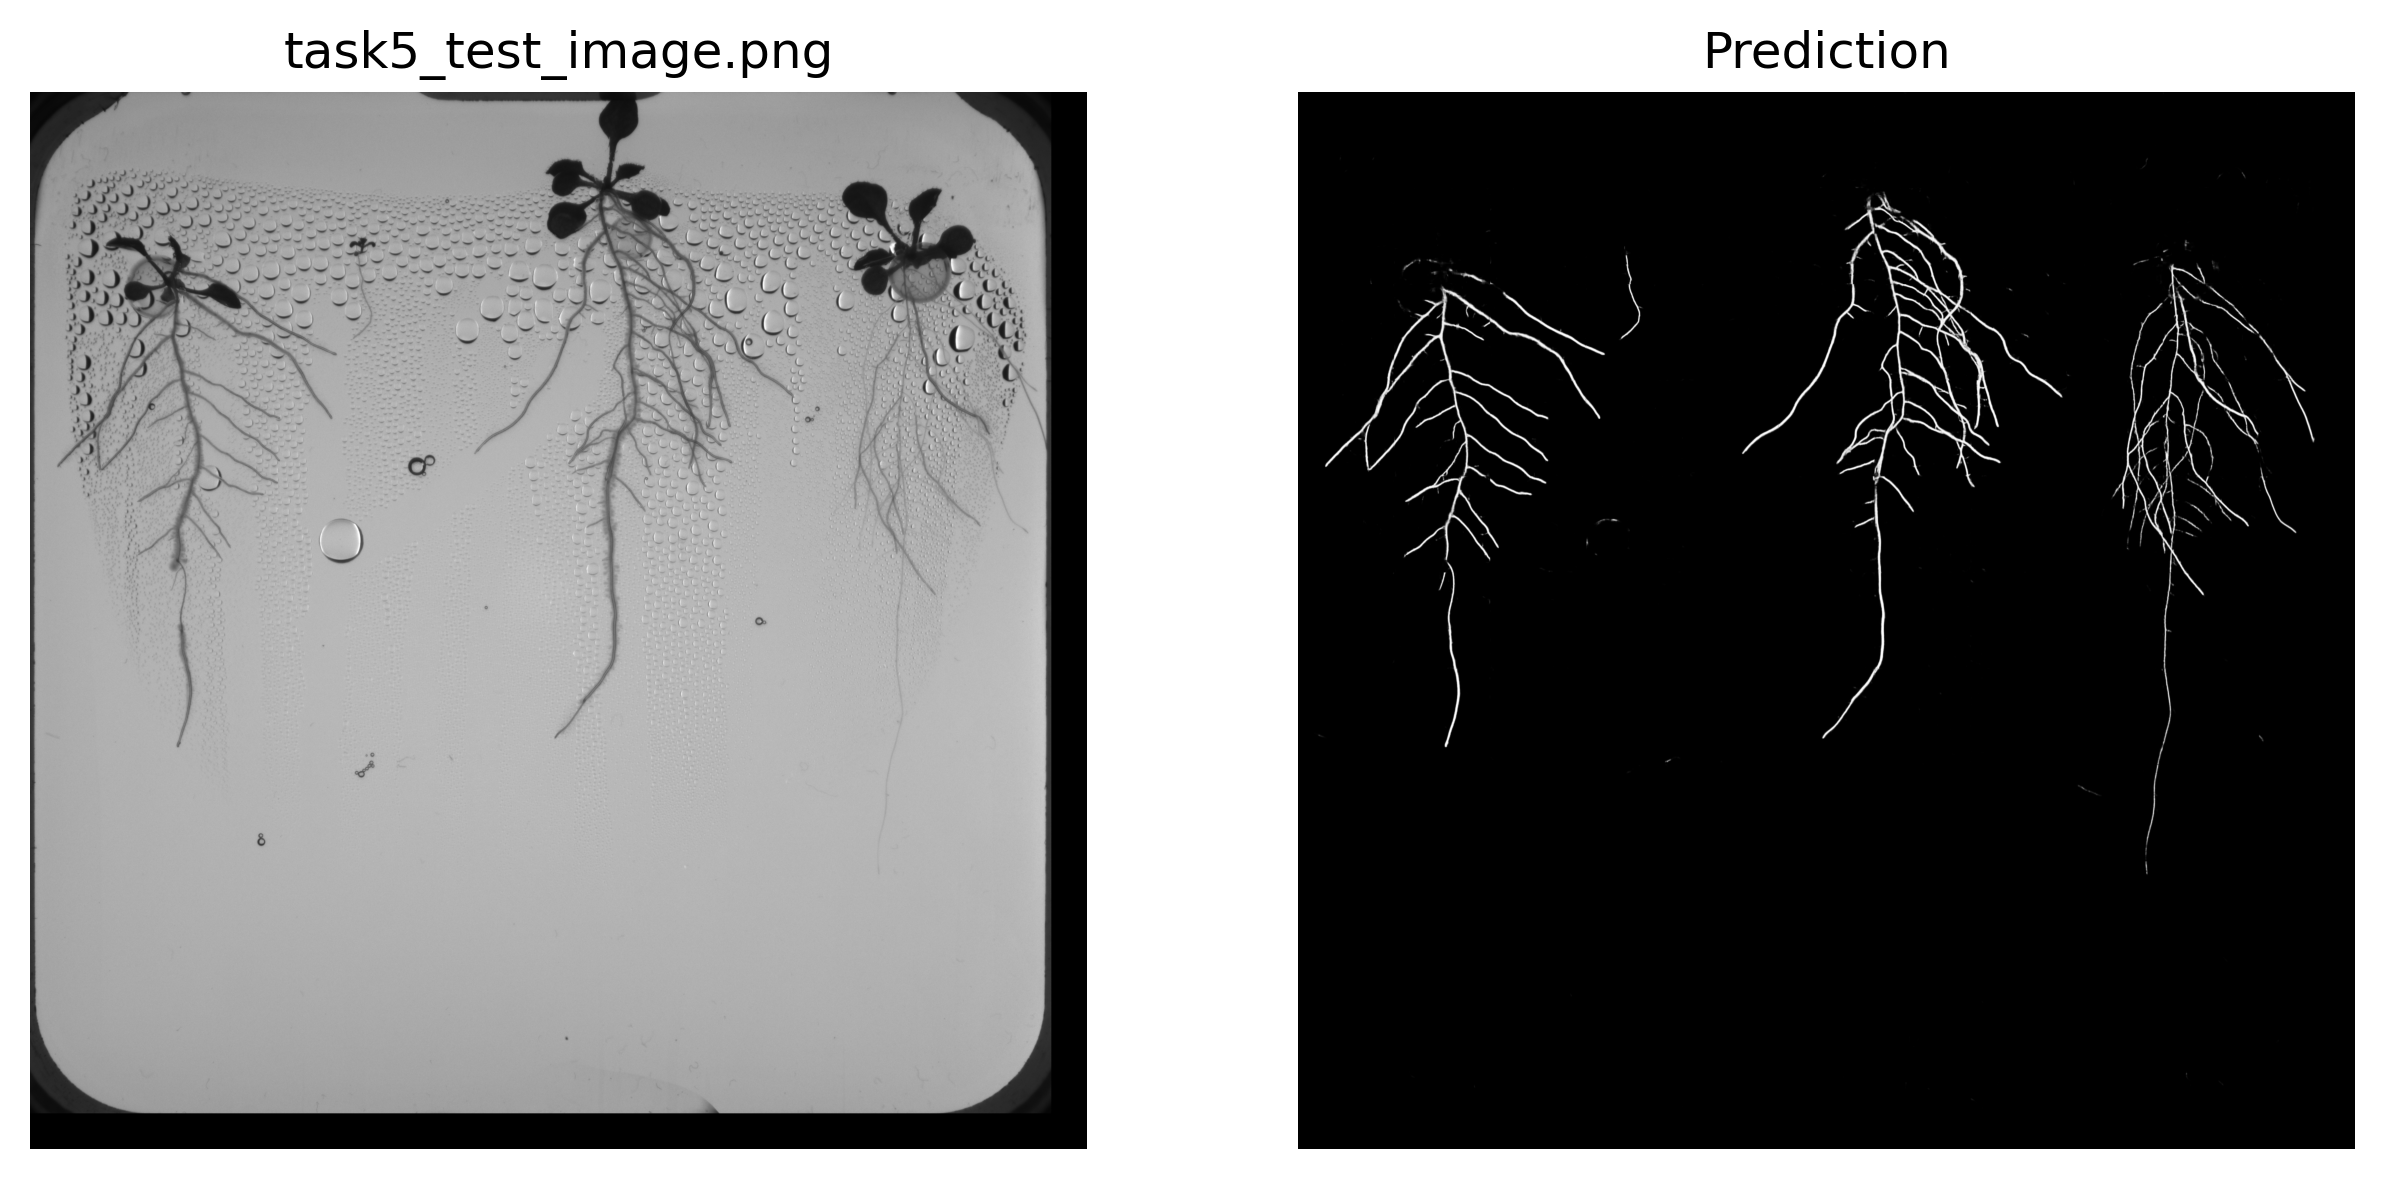

In [10]:
# UNPATCH
# Reconstruct the full mask from the predicted patches.
# This combines all the predicted patches back into a single image of the original dimensions.
predicted_mask = unpatchify(predicted_patches, petri_dish_padded.shape[:2])

# DISPLAY RESULTS
# Create a side-by-side plot to compare the original Petri dish image and the predicted mask.
f, ax = plt.subplots(1, 2, dpi=300, figsize=(10, 5))

# Display the padded Petri dish image.
ax[0].imshow(petri_dish_padded, cmap='gray')
ax[0].axis('off')  # Hide the axes for better visualization
ax[0].set_title('task5_test_image.png')  # Set the title for the original image

# Display the reconstructed predicted mask.
ax[1].imshow(predicted_mask, cmap='gray')
ax[1].axis('off')  # Hide the axes for better visualization
ax[1].set_title('Prediction')  # Set the title for the predicted mask

In [11]:
predicted_mask.shape, image.shape

((2816, 2816), (3006, 4112))

As you can see `predicted_mask` and `image` have different shapes. This is because of cropping and padding.

**REQUIREMENT:** The input and output should have the same size and should be aligned perfectly. To achieve this, you need to reverse the effects of cropping and padding added during processing. This will ensure the final mask aligns with the original image.

In [12]:
# Apply the corrections
# Function to align the predicted mask with the original image dimensions.
def align_mask_to_original(predicted_mask, original_image, crop_coordinates):
    # Get the dimensions of the original image.
    h, w = original_image.shape[:2]  
    
    # Initialize an empty mask of the same size as the original image.
    # This will store the aligned predicted mask.
    aligned_mask = np.zeros((h, w), dtype=np.float32)  
    
    # Extract the crop coordinates from the bounding box (x_start, y_start, x_end, y_end).
    x_start, y_start, x_end, y_end = crop_coordinates  
    
    # Adjustment for bounding box dimensions to ensure proper alignment.
    # This accounts for possible border or size mismatches.
    adjustment = 100  
    x_end += adjustment
    y_end += adjustment
    
    # Calculate the height and width of the cropped region.
    cropped_h, cropped_w = y_end - y_start, x_end - x_start  
    
    # Resize the predicted mask to match the dimensions of the cropped region.
    # This ensures that the mask fits perfectly into the cropped area.
    resized_mask = cv2.resize(predicted_mask, (cropped_w, cropped_h), interpolation=cv2.INTER_LINEAR)
    
    # Place the resized mask into the aligned mask at the specified coordinates.
    # The resized mask is positioned within the bounding box (x_start, y_start) to (x_end, y_end).
    aligned_mask[y_start:y_end, x_start:x_end] = resized_mask  
    
    # Return the aligned mask with the corrections applied.
    return aligned_mask

# Correct and align the predicted mask
# Use the function to align the predicted mask with the original image dimensions.
predicted_mask_corrected = align_mask_to_original(predicted_mask, original_image, crop_coordinates)

# Display the shape of the corrected and aligned mask to verify its dimensions.
predicted_mask_corrected.shape

(3006, 4112)

Text(0.5, 1.0, 'Overlay: Original Image with Predicted Mask')

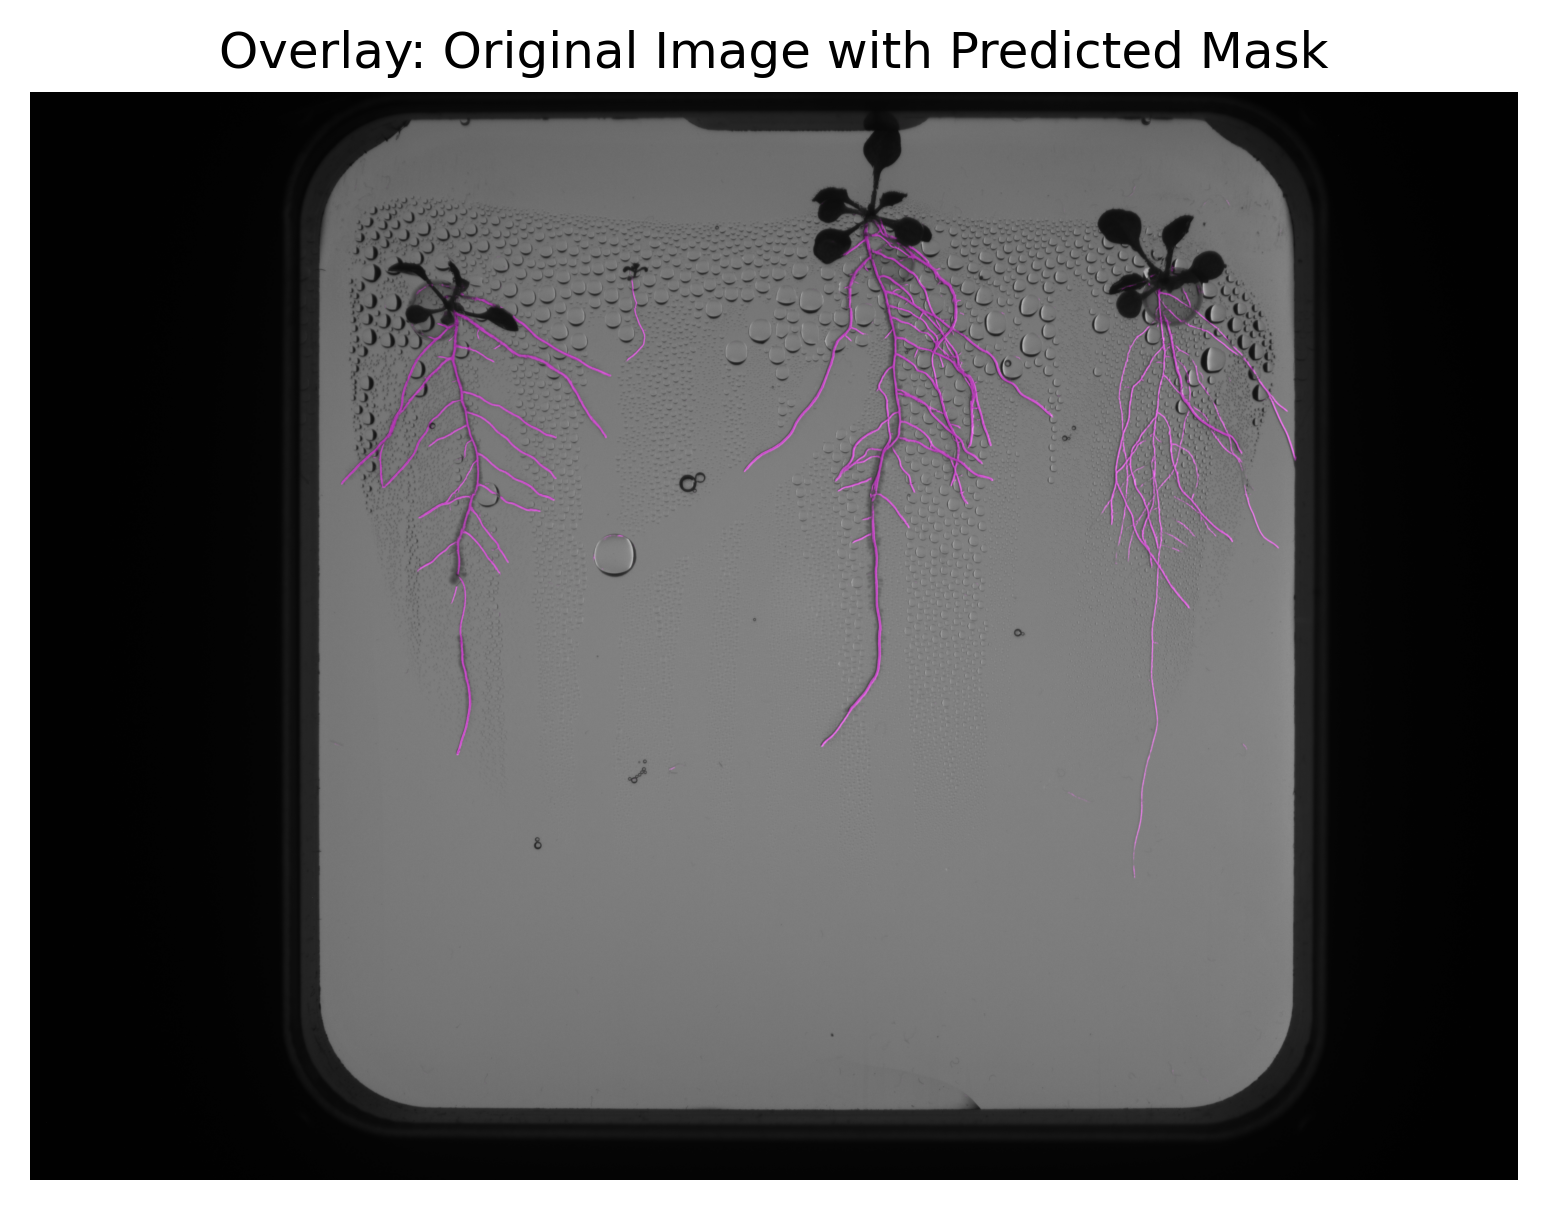

In [13]:
# REQUIREMENT: Predicted roots must align with the original image.
# REQUIREMENT: Plot such an image to prove alignment.

# Overlay prediction on the original image
# Initialize an empty image for the predicted mask with the same dimensions as the original image.
predicted_mask_colored = np.zeros_like(original_image, dtype=np.uint8)

# Set the red and blue channels to create a pink overlay.
# Multiply the corrected mask by 255 to scale it to the range [0, 255].
predicted_mask_colored[:, :, 0] = (predicted_mask_corrected * 255).astype(np.uint8)  # Blue channel
predicted_mask_colored[:, :, 2] = (predicted_mask_corrected * 255).astype(np.uint8)  # Red channel

# Overlay the pink mask on the original image using alpha blending.
# The `cv2.addWeighted` function combines the original image and the mask:
# - `original_image` is weighted by 0.7 (background contribution).
# - `predicted_mask_colored` is weighted by 0.5 (mask contribution).
# - The last parameter (0) adds a constant brightness offset (set to 0 here).
overlay_image = cv2.addWeighted(original_image, 0.7, predicted_mask_colored, 0.5, 0)

# Display the overlay image
# Use Matplotlib to visualize the result, converting from BGR (OpenCV format) to RGB.
plt.figure(dpi=300)  # Set high resolution for better visualization.
plt.imshow(cv2.cvtColor(overlay_image, cv2.COLOR_BGR2RGB))  # Convert to RGB for correct color rendering.
plt.axis('off')  # Hide axes for a cleaner display.
plt.title('Overlay: Original Image with Predicted Mask')  # Add a title for clarity.


In [14]:
# REQUIREMENT: Save the predicted mask, it is a deliverable.
# REQUIREMENT: Input/Output size must be the same.
# REQUIREMENT: Predicted roots must align with the original image.
# REQUIREMENT: The predicted mask must be binary.
# REQUIREMENT: Non-root pixels must be 0, root pixels must be 255 (unlike Task 1)
# REQUIREMENT: naming convention task5_test_image_prediction_studentname_studentnumber.png
mask_image = (predicted_mask_corrected * 255).astype(np.uint8)
assert predicted_mask_corrected.shape == image.shape
prediction_file_name = 'task5_test_image_prediction_anastasiia_234301.png'
cv2.imwrite(prediction_file_name, mask_image)

True

Note: I have trained the model on the Y2B_23 dataset, since there are no labels for Y2B_24 dataset yet. The test image is from Y2B_24, this is why the predicted mask is suboptimal. Therefore do not take the performance of this prediction as a reference. Your predictions should be much better than this.